In [ ]:
import pandas as pd            # Data manipulation
import numpy as np             # Numerical operations

import matplotlib.pyplot as plt       # Plotting graphs
import seaborn as sns                 # Advanced visualization

from sklearn.model_selection import train_test_split    # Splitting data
from sklearn.preprocessing import StandardScaler        # Feature scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  # Encoding categoricals
from sklearn.compose import ColumnTransformer           # For encoding pipelines

from sklearn.linear_model import LogisticRegression     # Logistic Regression
from sklearn.tree import DecisionTreeClassifier         # Decision Tree
from sklearn.ensemble import RandomForestClassifier      # Random Forest

#import plotly.express as px       # Interactive plots (optional)
import warnings
warnings.filterwarnings('ignore') # Suppress warnings

In [ ]:
df = pd.read_csv("/content/data.csv")

In [ ]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [ ]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [ ]:
df.dtypes

,0
id,int64
Gender,object
Age,int64
Driving_License,int64
Region_Code,float64
Previously_Insured,int64
Vehicle_Age,object
Vehicle_Damage,object
Annual_Premium,float64
Policy_Sales_Channel,float64


Gender
Male      206089
Female    175020
Name: count, dtype: int64
Gender
Male      54.07613
Female    45.92387
Name: proportion, dtype: float64


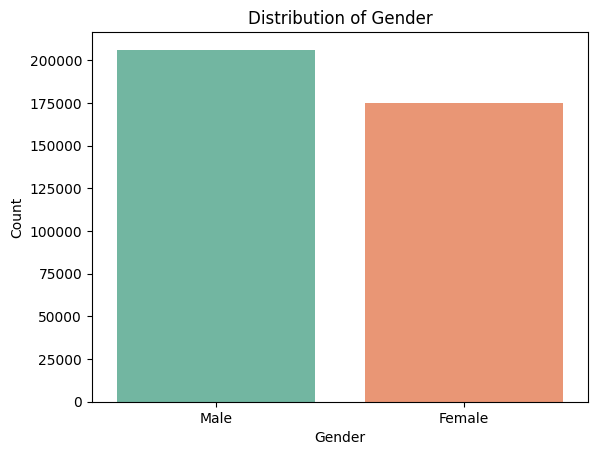

In [ ]:
#Univariate Analysis

# Count of each gender
print(df['Gender'].value_counts())

# Percentage distribution
print(df['Gender'].value_counts(normalize=True) * 100)

# Plot
sns.countplot(data=df, x='Gender', palette='Set2')
plt.title('Distribution of Gender')
plt.ylabel('Count')
plt.show()

Response       0      1
Gender                 
Female    156835  18185
Male      177564  28525
Response          0          1
Gender                        
Female    89.609759  10.390241
Male      86.158893  13.841107


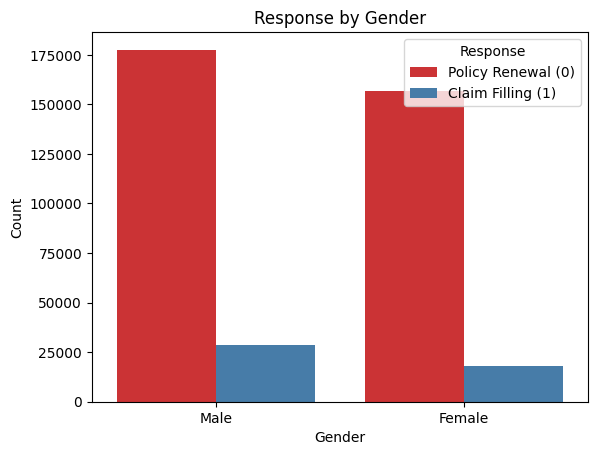

In [ ]:
#Bivariate Analysis

# Crosstab (counts)
print(pd.crosstab(df['Gender'], df['Response']))

# Crosstab (normalized by gender)
print(pd.crosstab(df['Gender'], df['Response'], normalize='index') * 100)

# Count plot with hue
sns.countplot(data=df, x='Gender', hue='Response', palette='Set1')
plt.title('Response by Gender')
plt.ylabel('Count')
plt.legend(title='Response', labels=['Policy Renewal (0)', 'Claim Filling (1)'])
plt.show()

Vehicle_Damage     No     Yes
Gender                       
Female          95355   79665
Male            93341  112748
Vehicle_Damage         No        Yes
Gender                              
Female          54.482345  45.517655
Male            45.291597  54.708403


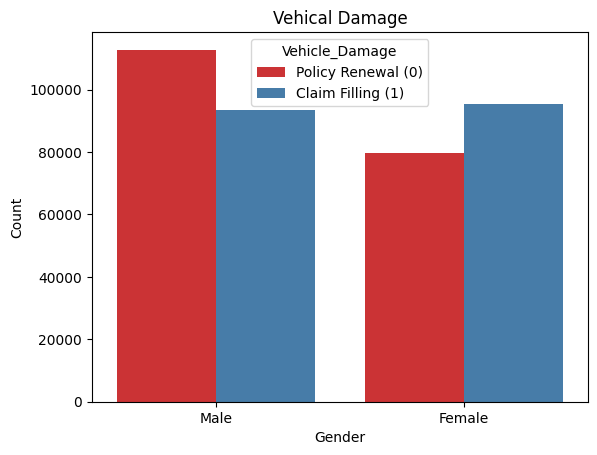

In [ ]:
# Crosstab (counts)
print(pd.crosstab(df['Gender'], df['Vehicle_Damage']))

# Crosstab (normalized by gender)
print(pd.crosstab(df['Gender'], df['Vehicle_Damage'], normalize='index') * 100)

# Count plot with hue
sns.countplot(data=df, x='Gender', hue='Vehicle_Damage', palette='Set1')
plt.title('Vehical Damage')
plt.ylabel('Count')
plt.legend(title='Vehicle_Damage', labels=['Policy Renewal (0)', 'Claim Filling (1)'])
plt.show()

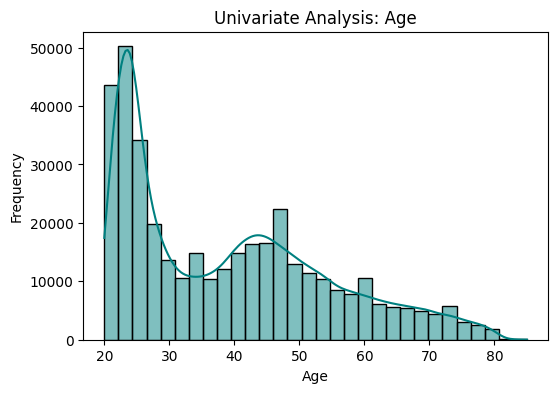

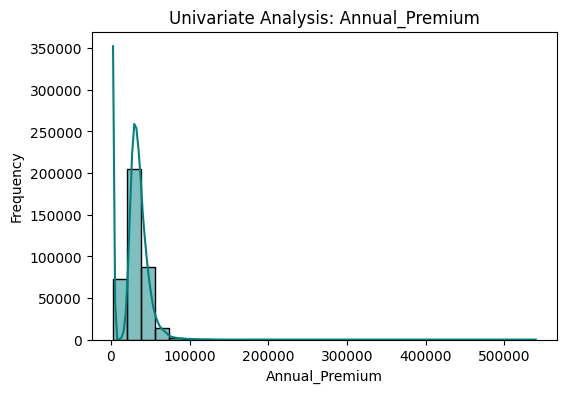

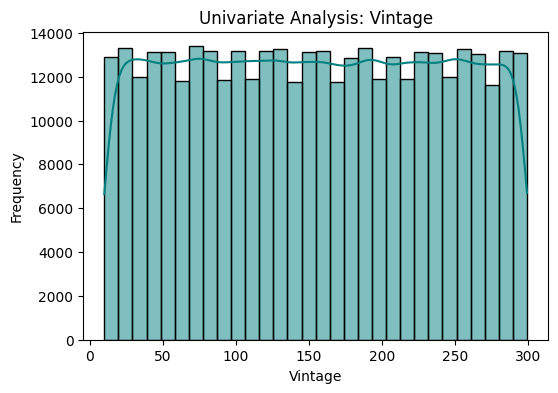

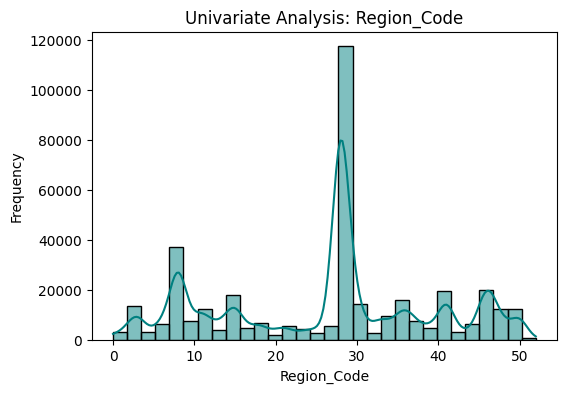

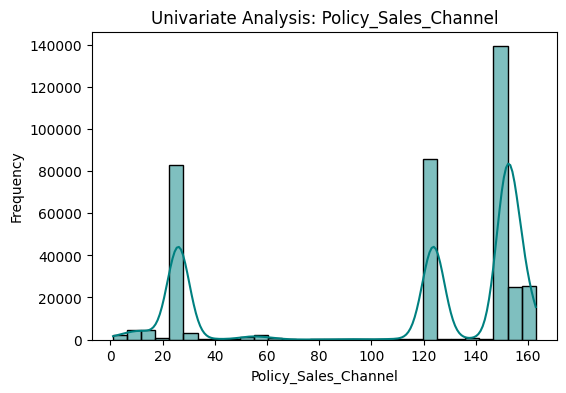

In [ ]:
numerical_cols = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code', 'Policy_Sales_Channel']

import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(f'Univariate Analysis: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

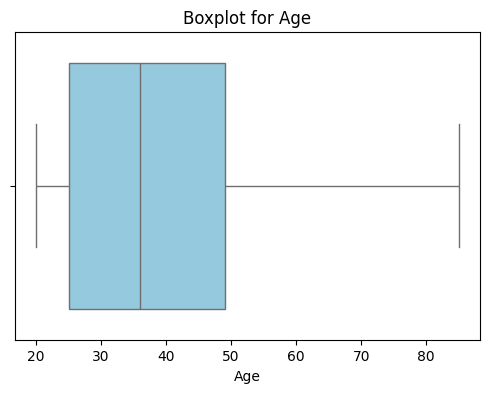

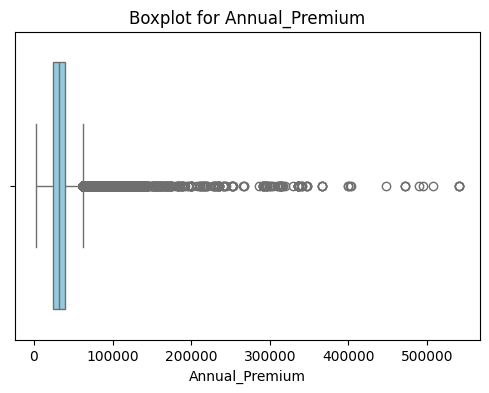

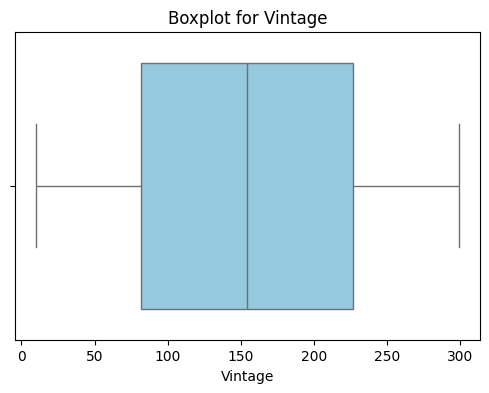

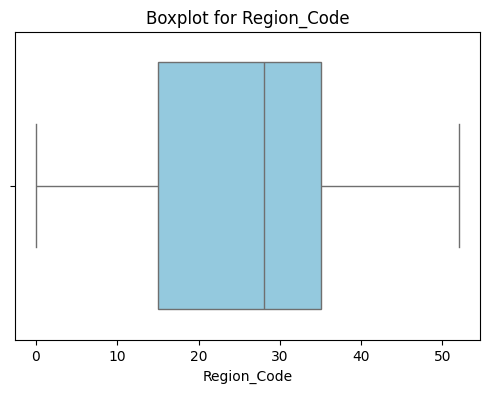

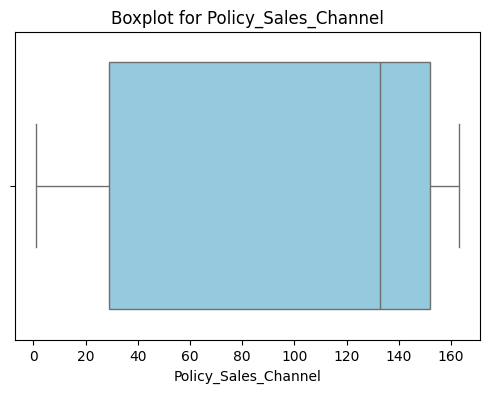

In [ ]:
numerical_cols = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code', 'Policy_Sales_Channel']

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.show()

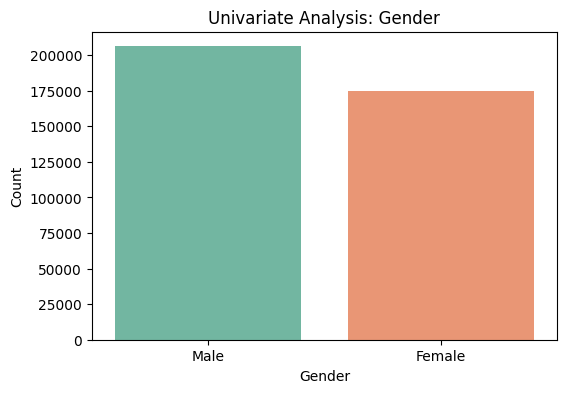

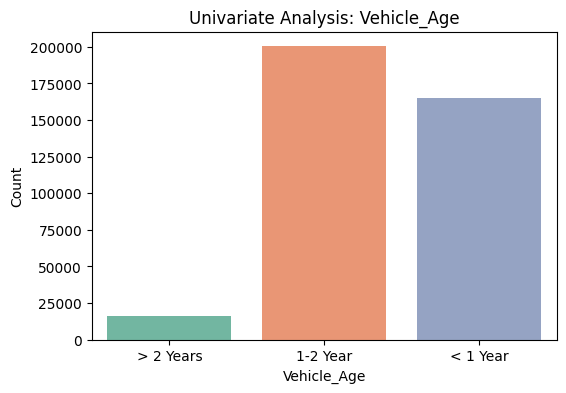

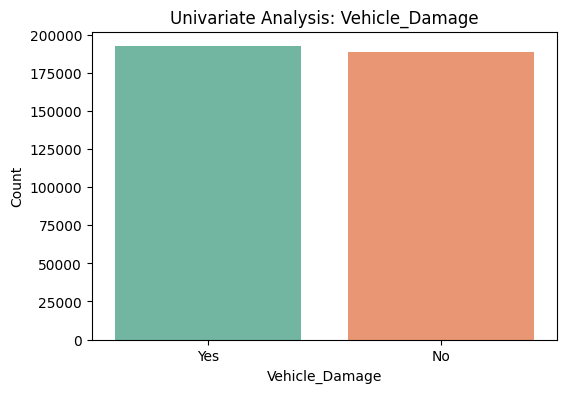

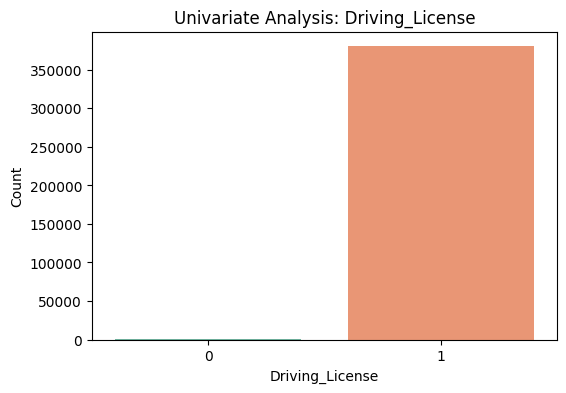

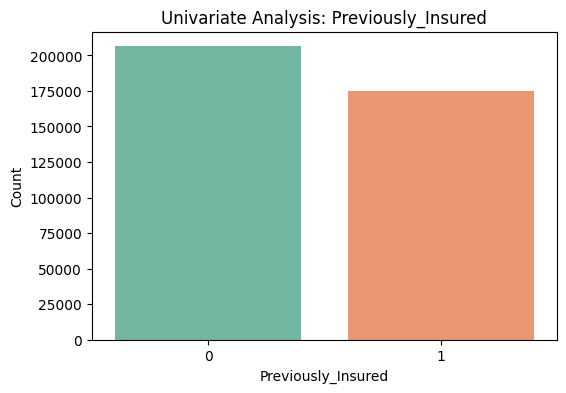

In [ ]:
categorical_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Driving_License', 'Previously_Insured']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, palette='Set2')
    plt.title(f'Univariate Analysis: {col}')
    plt.ylabel('Count')
    plt.show()

In [ ]:
#for col in ['Driving_License', 'Previously_Insured']:
#    print(f"{col} Value Counts:")
#    print(df[col].value_counts(), "\n")

In [ ]:
df = df.drop(columns=['id'], axis = True)

In [ ]:
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])                 # Male=1, Female=0
df['Vehicle_Damage'] = le.fit_transform(df['Vehicle_Damage']) # Yes=1, No=0
df['Vehicle_Age'] = le.fit_transform(df['Vehicle_Age'])       # <1=0, 1-2=1, >2=2

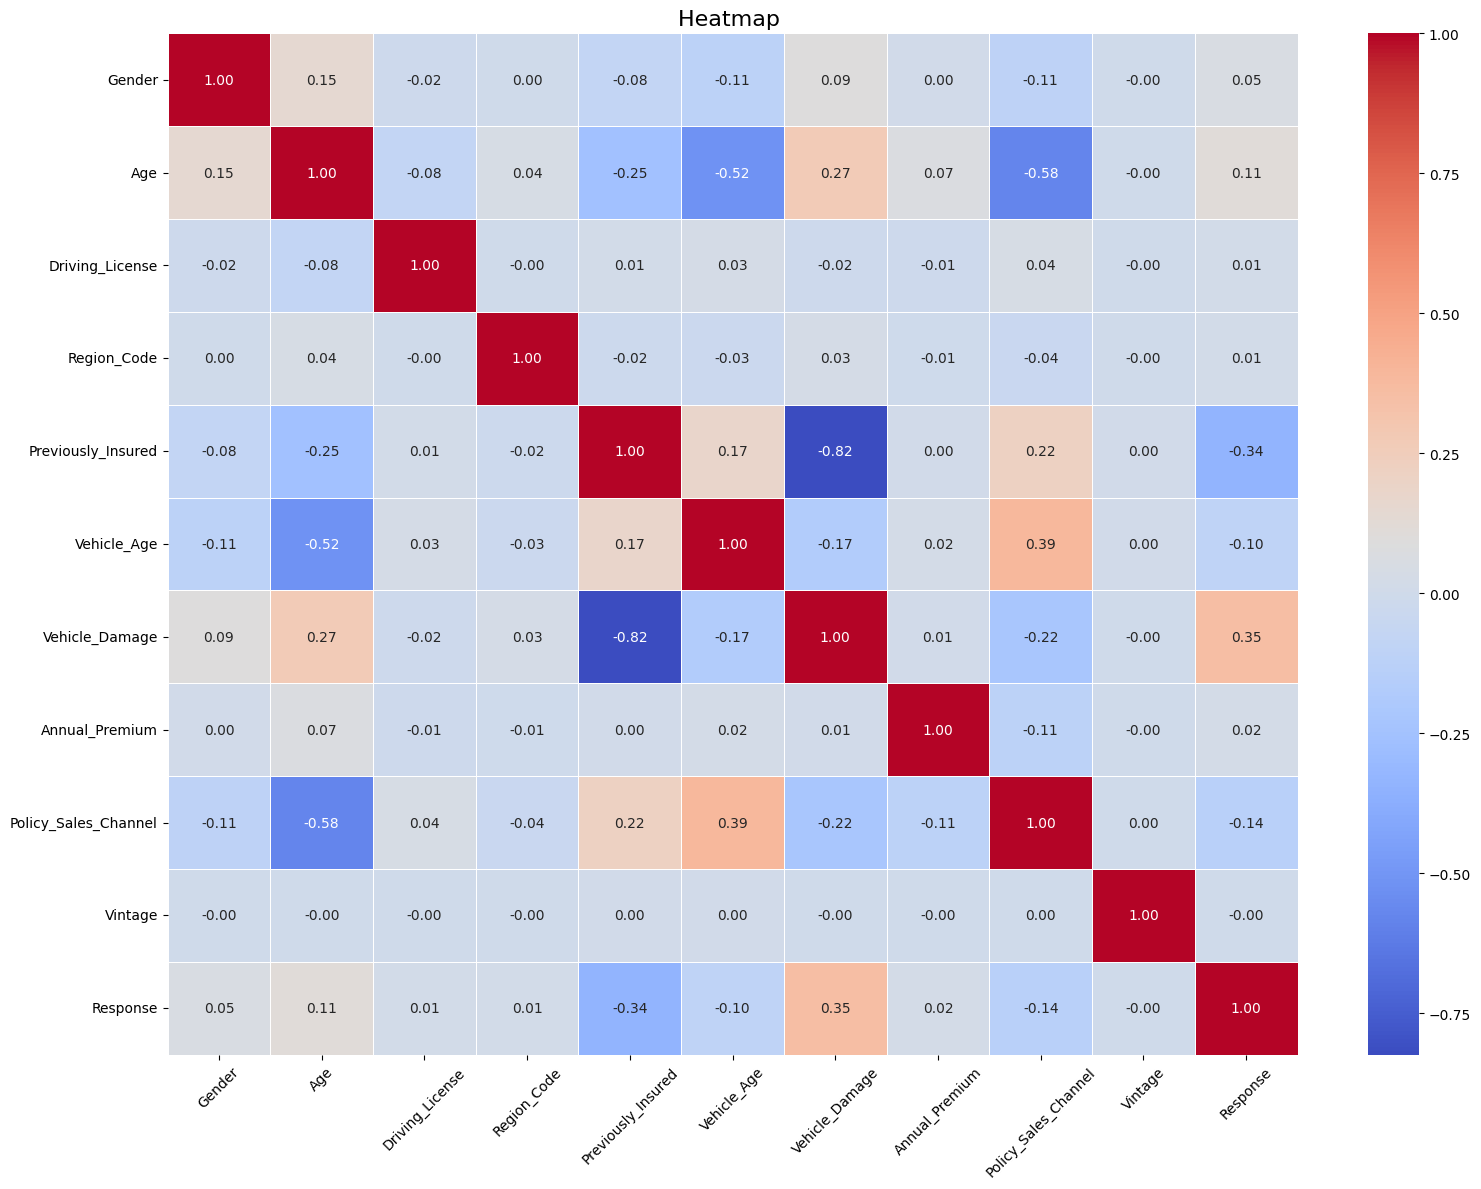

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Heatmap ", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_features = ['Age','Driving_License','Region_Code','Previously_Insured',
                'Annual_Premium','Policy_Sales_Channel','Vintage']

df[num_features] = scaler.fit_transform(df[num_features])

In [ ]:
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,0.333777,0.046208,0.121784,-0.919638,2,1,0.574539,-1.587234,0.748795,1
1,1,2.396751,0.046208,-1.767879,-0.919638,0,0,0.172636,-1.587234,0.342443,0
2,1,0.527181,0.046208,0.121784,-0.919638,2,1,0.449053,-1.587234,-1.521998,1
3,1,-1.148985,0.046208,-1.163187,1.087384,1,0,-0.113018,0.737321,0.581474,0
4,0,-0.633242,0.046208,1.104409,1.087384,1,0,-0.178259,0.737321,-1.378580,0


In [ ]:
df['Response'].value_counts()

,count
Response,
0,334399
1,46710


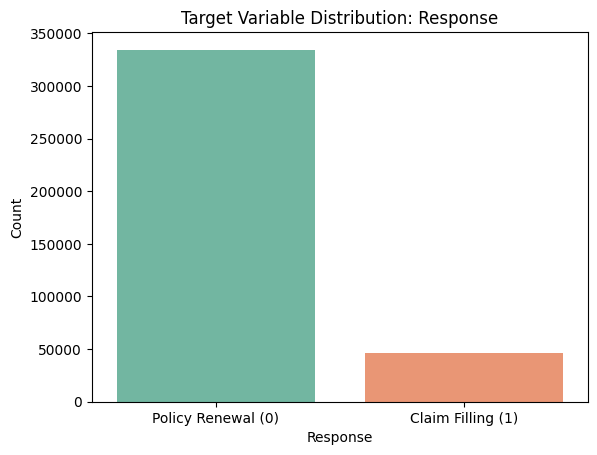

In [ ]:
sns.countplot(data=df, x='Response', palette='Set2')
plt.title('Target Variable Distribution: Response')
plt.xlabel('Response')
plt.ylabel('Count')
plt.xticks([0, 1], ['Policy Renewal (0)', 'Claim Filling (1)'])
plt.show()

In [ ]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the values
    df[column] = df[column].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

    print(f"Outliers capped for: {column}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

In [ ]:
numerical_cols = ['Age', 'Annual_Premium', 'Vintage', 'Policy_Sales_Channel', 'Region_Code']

for col in numerical_cols:
    cap_outliers_iqr(df, col)

Outliers capped for: Age
Lower Bound: -3.2119583757358647, Upper Bound: 2.9769620295319648
Outliers capped for: Annual_Premium
Lower Bound: -1.664536633571104, Upper Bound: 1.8200121602440236
Outliers capped for: Vintage
Lower Bound: -3.4641240710101475, Upper Bound: 3.4677717618445016
Outliers capped for: Policy_Sales_Channel
Lower Bound: -4.935699790338382, Upper Bound: 4.1411338919296155
Outliers capped for: Region_Code
Lower Bound: -3.1284362816579985, Upper Bound: 2.9184860204140493


In [ ]:
#numerical_cols = ['Age', 'Annual_Premium', 'Vintage', 'Region_Code', 'Policy_Sales_Channel']

#for col in numerical_cols:
#    plt.figure(figsize=(6, 4))
#    sns.boxplot(x=df[col], color='skyblue')
#    plt.title(f'Boxplot for {col}')
#    plt.xlabel(col)
#    plt.show()

In [ ]:
#!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop('Response', axis=1)
y = df['Response']  # still binary 0/1

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check balance
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Response
0    267519
1     37368
Name: count, dtype: int64
After SMOTE: Response
0    267519
1    267519
Name: count, dtype: int64


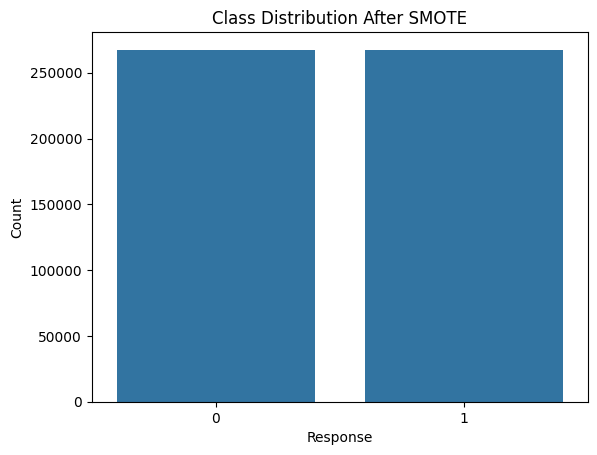

In [ ]:
sns.countplot(x=y_train_smote)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Response")
plt.ylabel("Count")
plt.show()

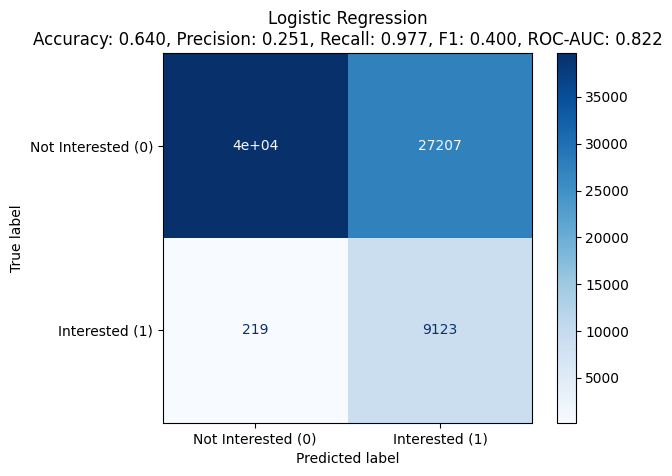

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

# Predict
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc = roc_auc_score(y_test, y_proba_lr)

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Interested (0)', 'Interested (1)'])
disp.plot(cmap='Blues')
plt.title(f"Logistic Regression\nAccuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}, ROC-AUC: {roc:.3f}")
plt.grid(False)
plt.show()

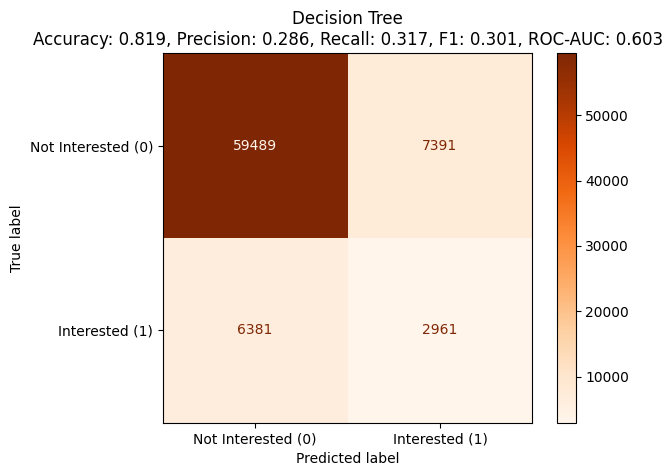

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_dt)
prec = precision_score(y_test, y_pred_dt)
rec = recall_score(y_test, y_pred_dt)
f1 = f1_score(y_test, y_pred_dt)
roc = roc_auc_score(y_test, y_proba_dt)

cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Interested (0)', 'Interested (1)'])
disp.plot(cmap='Oranges')
plt.title(f"Decision Tree\nAccuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}, ROC-AUC: {roc:.3f}")
plt.grid(False)
plt.show()

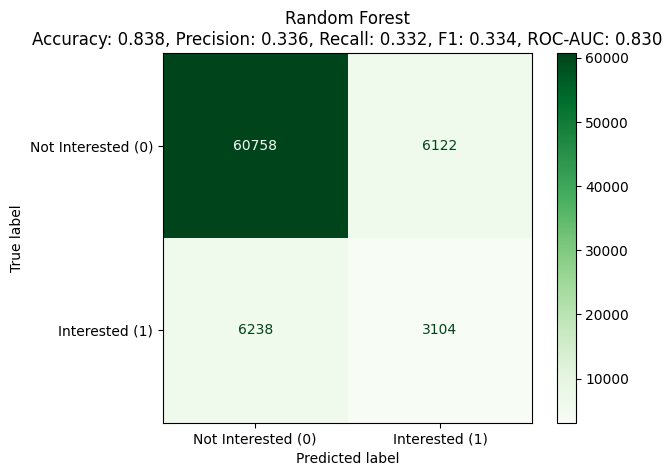

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred_rf)
prec = precision_score(y_test, y_pred_rf)
rec = recall_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
roc = roc_auc_score(y_test, y_proba_rf)

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Interested (0)', 'Interested (1)'])
disp.plot(cmap='Greens')
plt.title(f"Random Forest\nAccuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}, ROC-AUC: {roc:.3f}")
plt.grid(False)
plt.show()

In [ ]:
# Get probabilities for class 1 (interested)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Try a threshold (you can change this value)
threshold = 0.4  # Make model more conservative

# Convert probabilities to predicted class based on threshold
y_pred_thresh = (y_proba_rf >= threshold).astype(int)

# Evaluate
print(f"Threshold: {threshold}")
print(confusion_matrix(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh, digits=4))

Threshold: 0.4
[[56762 10118]
 [ 4607  4735]]
              precision    recall  f1-score   support

           0     0.9249    0.8487    0.8852     66880
           1     0.3188    0.5069    0.3914      9342

    accuracy                         0.8068     76222
   macro avg     0.6219    0.6778    0.6383     76222
weighted avg     0.8506    0.8068    0.8247     76222



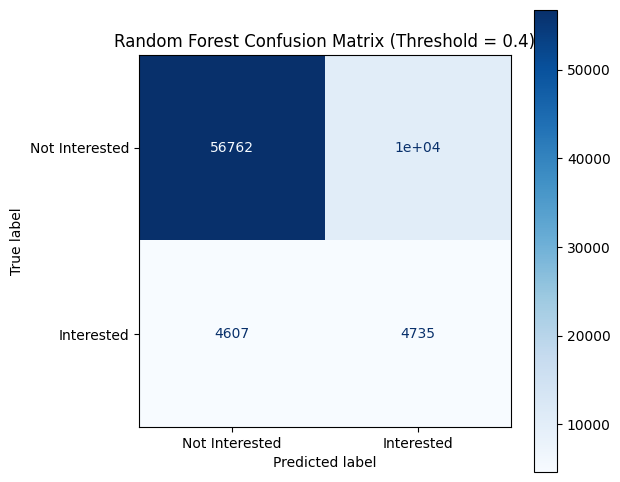

In [ ]:
#Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_thresh)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Interested", "Interested"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title(f"Random Forest Confusion Matrix (Threshold = {threshold})")
plt.grid(False)
plt.show()

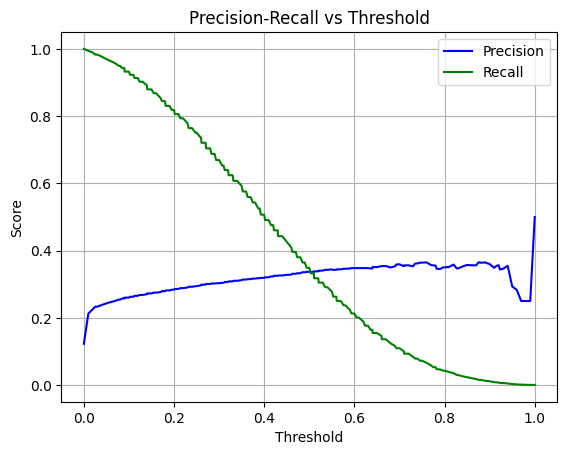

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)

plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='green')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()